In [0]:
# ============================================================================
# APLICAR MODELO CARREGADO EM NOVAS BASES
# ============================================================================

import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("APLICAÇÃO DE MODELO CARREGADO EM NOVAS BASES")
print("="*80)

APLICAÇÃO DE MODELO CARREGADO EM NOVAS BASES


In [0]:
# ============================================================================
# 1. CARREGAR MODELO
# ============================================================================

print("\n📦 CARREGANDO MODELO...")

# Definir caminho do modelo
caminho_modelo = "/Workspace/Users/eduardoandrechuk@outlook.com/pkl/modelo_regressao_final_20260210_1252.pkl"

try:
    with open(caminho_modelo, 'rb') as arquivo:
        modelo_carregado = pickle.load(arquivo)
    
    print(f"✅ Modelo carregado com sucesso!")
    print(f"Tipo: {type(modelo_carregado)}")
    
    # Verificar se tem métodos necessários
    if hasattr(modelo_carregado, 'predict_proba'):
        print("✅ Método predict_proba disponível")
    if hasattr(modelo_carregado, 'predict'):
        print("✅ Método predict disponível")
        
except Exception as e:
    print(f"❌ Erro ao carregar modelo: {str(e)}")
    exit()


📦 CARREGANDO MODELO...
✅ Modelo carregado com sucesso!
Tipo: <class 'statsmodels.discrete.discrete_model.BinaryResultsWrapper'>
✅ Método predict disponível


In [0]:
# ============================================================================
# 2. CARREGAR E PREPARAR DADOS
# ============================================================================

print("\n📊 CARREGANDO DADOS...")

from pyspark.sql import SparkSession
import pyspark.sql.functions as F

# Carregar dados com schema específico
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, LongType, DoubleType

# Definir schema exato
schema = StructType([
    StructField("safra", StringType(), True),
    StructField("num_cpf", StringType(), True),
    StructField("fpd_int", IntegerType(), True),
    StructField("score_01_adj", DoubleType(), True),
    StructField("score_02_adj", DoubleType(), True),
    StructField("idade_anos", LongType(), True),
    StructField("ticket_medio_m1", DoubleType(), True),
    StructField("qtd_sos_m6", LongType(), True),
    StructField("qtd_combo_m6", LongType(), True),
    StructField("val_liquido_m6", DoubleType(), True),
    StructField("sum_val_aberto_mes_atr_m1", DoubleType(), True),
    StructField("qtd_meses_dados_pag_m6", LongType(), True),
    StructField("sum_val_pago_mes_pag_m1", DoubleType(), True),
    StructField("flag_teve_fraude_mes_atr_m1", IntegerType(), True),
    StructField("PROD", StringType(), True),
    StructField("flag_mig2", StringType(), True),
    StructField("flag_idade_menor_18", IntegerType(), True),
    StructField("flag_idade_muito_alta", IntegerType(), True),
    StructField("flag_instalacao_int", IntegerType(), True)
])

print("📋 Schema definido com tipos específicos")

# Carregar dados Delta
delta = spark.read.schema(schema).parquet('/Volumes/workspace/hackathon_2025/default/source/abt_final_qualificação/')
delta = delta.filter(
    (F.col('PROD') == 'CMV') & 
    (F.col('flag_mig2') == 'PRE') & 
    (F.col('flag_instalacao_int') == 1) &
    (F.col('idade_anos').isNotNull()) &
    (F.col('flag_idade_menor_18') == 0) &
    (F.col('flag_idade_muito_alta') == 0)
)

print(f"✅ Dados carregados - Total: {delta.count():,} registros")

# ============================================================================
# CRIAR DATAFRAME COM SCORES E VARIÁVEIS CATEGORIZADAS
# ============================================================================

print("🔧 Aplicando categorizações...")

delta_cate = (delta
    # Categorização SCORE_01
    .withColumn(
        "score_01_adj_cate",
        F.expr("""
            CASE 
                WHEN (score_01_adj) IS NULL THEN  8
                WHEN (score_01_adj) <= 500   THEN 8
                WHEN (score_01_adj) <= 550   THEN 7
                WHEN (score_01_adj) <= 575   THEN 6
                WHEN (score_01_adj) <= 600   THEN 5
                WHEN (score_01_adj) <= 625   THEN 4
                WHEN (score_01_adj) <= 650   THEN 3
                WHEN (score_01_adj) <= 675   THEN 2
                WHEN (score_01_adj) <= 1000  THEN 1
                ELSE 0
            END
        """)
    )
    # Categorização SCORE_02
    .withColumn(
        "score_02_adj_cate",
        F.expr("""
            CASE 
                WHEN (score_02_adj) IS NULL THEN  10
                WHEN (score_02_adj) <= 490   THEN 10
                WHEN (score_02_adj) <= 530   THEN 9
                WHEN (score_02_adj) <= 550   THEN 8
                WHEN (score_02_adj) <= 575   THEN 7
                WHEN (score_02_adj) <= 625   THEN 6
                WHEN (score_02_adj) <= 650   THEN 5
                WHEN (score_02_adj) <= 700   THEN 4
                WHEN (score_02_adj) <= 750   THEN 3
                WHEN (score_02_adj) <= 800   THEN 2
                WHEN (score_02_adj) <= 1000  THEN 1
                ELSE 0
            END
        """)
    )
    .withColumn(
        "IDADE_cate",
        F.expr("""
            CASE 
                WHEN idade_anos <= 35        THEN 3
                WHEN idade_anos <= 55        THEN 2
                WHEN idade_anos > 55         THEN 1
                ELSE 999
            END
        """))
    # ============================================================================
    # VARIÁVEIS DE RECARGA SIMPLIFICADAS (MODELO 5)
    # ============================================================================
    # ticket_medio_m1
    .withColumn(
        "ticket_medio_m1_cate",
        F.expr("""
            CASE 
                WHEN (ticket_medio_m1) IS NULL THEN 3
                WHEN (ticket_medio_m1) < 5.44 THEN 3
                WHEN (ticket_medio_m1) < 14.98 THEN 2
                WHEN (ticket_medio_m1) >= 14.98 THEN 1
                ELSE 999
            END
        """)
    )
    .withColumn(
        "qtd_sos_m6_cate",
        F.expr("""
            CASE 
                WHEN (qtd_sos_m6) IS NULL THEN 0
                WHEN (qtd_sos_m6) <= 1 THEN 1
                WHEN (qtd_sos_m6) > 1 THEN 2
                ELSE 999
            END
        """)
    )
    # qtd_combo_m6
    .withColumn(
        "qtd_combo_m6_cate",
        F.expr("""
            CASE 
                WHEN (qtd_combo_m6) IS NULL THEN 0
                WHEN (qtd_combo_m6) < 0.5 THEN 1
                WHEN (qtd_combo_m6) >= 0.5 THEN 2
                ELSE 999
            END
        """)
    )
    .withColumn(
        "val_liquido_m6_cate",
        F.expr("""
            CASE 
                WHEN (val_liquido_m6) IS NULL THEN 4
                WHEN (val_liquido_m6) < 51.98 THEN 4
                WHEN (val_liquido_m6) < 99.94 THEN 3
                WHEN (val_liquido_m6) < 149.94 THEN 2
                WHEN (val_liquido_m6) >= 149.94 THEN 1
                ELSE 999
            END
        """)
    )
    # ============================================================================
    # VARIÁVEIS DE PAGAMENTO/ATRASO (MODELO 6)
    # ============================================================================

    # JANELA M1
    # sum_val_aberto_mes_atr_m1 (simplificada para 2 categorias)
    .withColumn(
        "sum_val_aberto_mes_atr_m1_cate",
        F.expr("""
            CASE 
                WHEN (sum_val_aberto_mes_atr_m1) IS NULL THEN 0
                WHEN (sum_val_aberto_mes_atr_m1) <= 25.00 THEN 1
                WHEN (sum_val_aberto_mes_atr_m1) > 25.00 THEN 2
                ELSE 999
            END
        """)
    )
    # sum_val_pago_mes_pag_m1
    .withColumn(
        "sum_val_pago_mes_pag_m1_cate",
        F.expr("""
            CASE 
                WHEN (sum_val_pago_mes_pag_m1) IS NULL THEN 0
                WHEN (sum_val_pago_mes_pag_m1) <= 20 THEN 3
                WHEN (sum_val_pago_mes_pag_m1) <= 80 THEN 2
                WHEN (sum_val_pago_mes_pag_m1) > 80 THEN 1
                ELSE 999
            END
        """)
    )
      
    # JANELA M6
    # qtd_meses_dados_pag_m6 (simplificada para 3 categorias)
    .withColumn(
        "qtd_meses_dados_pag_m6_cate",
        F.expr("""
            CASE 
                WHEN (qtd_meses_dados_pag_m6) IS NULL THEN 0
                WHEN (qtd_meses_dados_pag_m6) <= 3.5 THEN 3
                WHEN (qtd_meses_dados_pag_m6) <= 5.5 THEN 2
                WHEN (qtd_meses_dados_pag_m6) > 5.5 THEN 1
                ELSE 999
            END
        """)
    )
)

print("✅ Categorizações aplicadas")

# ============================================================================
# DEFINIR SAFRAS E SEPARAR DATASETS
# ============================================================================

# Colunas necessárias para modelagem
colunas_necessarias = [
    'safra',
    'num_cpf',
    'fpd_int',
    'score_01_adj_cate',
    'score_02_adj_cate',
    'IDADE_cate',
    'ticket_medio_m1_cate',
    'qtd_sos_m6_cate',
    'qtd_combo_m6_cate',
    'val_liquido_m6_cate',
    'sum_val_aberto_mes_atr_m1_cate',
    'qtd_meses_dados_pag_m6_cate',
    'sum_val_pago_mes_pag_m1_cate',
    'flag_teve_fraude_mes_atr_m1'
]

# Definir safras
safra_treino = [202410, 202411, 202412]
safra_validacao = [202501]
safra_oot = [202502, 202503]

print(f"📅 Safras definidas:")
print(f"  Treino: {safra_treino}")
print(f"  Validação: {safra_validacao}")
print(f"  OOT: {safra_oot}")

# Filtrar e selecionar colunas
delta_final = delta_cate.select(colunas_necessarias)

# Separar por safra e converter para Pandas
print("\n🔄 Separando datasets e convertendo para Pandas...")

df_treino = delta_final.filter(F.col('safra').isin(safra_treino)).toPandas()
df_validacao = delta_final.filter(F.col('safra').isin(safra_validacao)).toPandas()
df_oot = delta_final.filter(F.col('safra').isin(safra_oot)).toPandas()

print(f"✅ Datasets criados:")
print(f"  Treino: {len(df_treino):,} registros")
print(f"  Validação: {len(df_validacao):,} registros")  
print(f"  OOT: {len(df_oot):,} registros")

# Verificar distribuição da variável target
print(f"\n📊 Distribuição FPD:")
for nome, df in [('Treino', df_treino), ('Validação', df_validacao), ('OOT', df_oot)]:
    taxa_fpd = df['fpd_int'].mean() * 100
    print(f"  {nome}: {taxa_fpd:.2f}% FPD")


📊 CARREGANDO DADOS...
📋 Schema definido com tipos específicos
✅ Dados carregados - Total: 1,288,300 registros
🔧 Aplicando categorizações...
✅ Categorizações aplicadas
📅 Safras definidas:
  Treino: [202410, 202411, 202412]
  Validação: [202501]
  OOT: [202502, 202503]

🔄 Separando datasets e convertendo para Pandas...
✅ Datasets criados:
  Treino: 657,689 registros
  Validação: 220,658 registros
  OOT: 409,953 registros

📊 Distribuição FPD:
  Treino: 23.83% FPD
  Validação: 23.58% FPD
  OOT: 23.06% FPD


In [0]:
# ============================================================================
# 3. FUNÇÕES DE AVALIAÇÃO
# ============================================================================

def calcular_ks(y_real, y_proba):
    """Calcula KS"""
    # Criar DataFrame
    df = pd.DataFrame({'real': y_real, 'proba': y_proba})
    
    # Ordenar por probabilidade (decrescente)
    df = df.sort_values('proba', ascending=False).reset_index(drop=True)
    
    # Calcular percentis
    n_total = len(df)
    df['percentil'] = (df.index + 1) / n_total * 100
    
    # Calcular acumulados
    total_maus = df['real'].sum()
    total_bons = n_total - total_maus
    
    df['maus_acum'] = df['real'].cumsum()
    df['bons_acum'] = (df.index + 1) - df['maus_acum']
    
    # Calcular taxas
    df['taxa_maus'] = df['maus_acum'] / total_maus
    df['taxa_bons'] = df['bons_acum'] / total_bons
    
    # Calcular KS
    df['ks'] = abs(df['taxa_maus'] - df['taxa_bons'])
    
    # Encontrar KS máximo
    ks_max = df['ks'].max()
    ks_percentil = df[df['ks'] == ks_max]['percentil'].iloc[0]
    
    return ks_max, ks_percentil, df

def plot_curva_ks(df_ks, ks_valor, titulo):
    """Plota curva KS"""
    plt.figure(figsize=(10, 6))
    
    # Plotar curvas
    plt.plot(df_ks['percentil'], df_ks['taxa_maus'], 'b-', linewidth=2, label='Taxa de Maus')
    plt.plot(df_ks['percentil'], df_ks['taxa_bons'], 'r-', linewidth=2, label='Taxa de Bons')
    plt.plot(df_ks['percentil'], df_ks['ks'], 'g-', linewidth=2, label='KS')
    
    # Marcar KS máximo
    ks_max_idx = df_ks['ks'].idxmax()
    plt.plot(df_ks.loc[ks_max_idx, 'percentil'], ks_valor, 'go', markersize=8)
    plt.annotate(f'KS = {ks_valor*100:.2f}%', 
                xy=(df_ks.loc[ks_max_idx, 'percentil'], ks_valor),
                xytext=(df_ks.loc[ks_max_idx, 'percentil'] + 10, ks_valor + 0.05),
                arrowprops=dict(arrowstyle='->', color='green'))
    
    # Configurar
    plt.xlabel('Percentil da População', fontsize=11)
    plt.ylabel('Taxa Acumulada', fontsize=11)
    plt.title(f'{titulo}\nKS = {ks_valor*100:.2f}%', fontsize=13, fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [0]:
# ============================================================================
# 4. PREPARAR FEATURES PARA PREDIÇÃO
# ============================================================================

def preparar_features_modelo(df, features_necessarias):
    """
    Prepara features EXATAMENTE como o modelo foi treinado
    """
    print(f"📋 Preparando features")
    
    # Features que o modelo espera
    features_esperadas = [
        'const',
        'score_01_adj_cate_1', 'score_01_adj_cate_2', 'score_01_adj_cate_3', 
        'score_01_adj_cate_4', 'score_01_adj_cate_5', 'score_01_adj_cate_6', 'score_01_adj_cate_7',
        'score_02_adj_cate_1', 'score_02_adj_cate_2', 'score_02_adj_cate_3', 
        'score_02_adj_cate_4', 'score_02_adj_cate_5', 'score_02_adj_cate_6', 
        'score_02_adj_cate_7', 'score_02_adj_cate_8', 'score_02_adj_cate_9',
        'IDADE_cate_1', 'IDADE_cate_2',
        'ticket_medio_m1_cate_1', 'ticket_medio_m1_cate_2',
        'qtd_sos_m6_cate_1',
        'qtd_combo_m6_cate_1',
        'val_liquido_m6_cate_1', 'val_liquido_m6_cate_2', 'val_liquido_m6_cate_3',
        'sum_val_aberto_mes_atr_m1_cate_1',
        'qtd_meses_dados_pag_m6_cate_1', 'qtd_meses_dados_pag_m6_cate_2',
        'sum_val_pago_mes_pag_m1_cate_1', 'sum_val_pago_mes_pag_m1_cate_2',
        'flag_teve_fraude_mes_atr_m1'
    ]
    
    print(f"🎯 Modelo espera {len(features_esperadas)} features")
    
    # Verificar se todas as features base existem
    features_faltando = set(features_necessarias) - set(df.columns)
    if features_faltando:
        print(f"⚠️  Features faltando: {features_faltando}")
        return None
    
    X = df[features_necessarias].copy()
    
    # Criar DataFrame final com TODAS as features que o modelo espera
    X_final = pd.DataFrame()
    
    # ============================================================================
    # CRIAR CADA FEATURE EXATAMENTE COMO O MODELO ESPERA
    # ============================================================================
    
    print("🔧 Criando features exatas...")
    
    # 1. SCORE_01 (categorias 1-7, referência = 8)
    print("  Score 01...")
    for i in range(1, 8):  # 1 a 7
        X_final[f'score_01_adj_cate_{i}'] = (X['score_01_adj_cate'] == i).astype(int)
    
    # 2. SCORE_02 (categorias 1-9, referência = 10)  
    print("  Score 02...")
    for i in range(1, 10):  # 1 a 9
        X_final[f'score_02_adj_cate_{i}'] = (X['score_02_adj_cate'] == i).astype(int)
    
    # 3. IDADE (categorias 1-2, referência = 3)
    print("  Idade...")
    for i in range(1, 3):  # 1 a 2
        X_final[f'IDADE_cate_{i}'] = (X['IDADE_cate'] == i).astype(int)
    
    # 4. TICKET_MEDIO_M1 (categorias 1-2, referência = 3)
    print("  Ticket médio...")
    for i in range(1, 3):  # 1 a 2
        X_final[f'ticket_medio_m1_cate_{i}'] = (X['ticket_medio_m1_cate'] == i).astype(int)
    
    # 5. QTD_SOS_M6 (categoria 1, referência = 0 ou 2)
    print("  SOS M6...")
    X_final['qtd_sos_m6_cate_1'] = (X['qtd_sos_m6_cate'] == 1).astype(int)
    
    # 6. QTD_COMBO_M6 (categoria 1, referência = 0 ou 2)
    print("  Combo M6...")
    X_final['qtd_combo_m6_cate_1'] = (X['qtd_combo_m6_cate'] == 1).astype(int)
    
    # 7. VAL_LIQUIDO_M6 (categorias 1-3, referência = 4)
    print("  Valor líquido...")
    for i in range(1, 4):  # 1 a 3
        X_final[f'val_liquido_m6_cate_{i}'] = (X['val_liquido_m6_cate'] == i).astype(int)
    
    # 8. SUM_VAL_ABERTO_MES_ATR_M1 (categoria 1, referência = 0 ou 2)
    print("  Valor aberto...")
    X_final['sum_val_aberto_mes_atr_m1_cate_1'] = (X['sum_val_aberto_mes_atr_m1_cate'] == 1).astype(int)
    
    # 9. QTD_MESES_DADOS_PAG_M6 (categorias 1-2, referência = 0 ou 3)
    print("  Meses dados pagamento...")
    for i in range(1, 3):  # 1 a 2
        X_final[f'qtd_meses_dados_pag_m6_cate_{i}'] = (X['qtd_meses_dados_pag_m6_cate'] == i).astype(int)
    
    # 10. SUM_VAL_PAGO_MES_PAG_M1 (categorias 1-2, referência = 0 ou 3)
    print("  Valor pago...")
    for i in range(1, 3):  # 1 a 2
        X_final[f'sum_val_pago_mes_pag_m1_cate_{i}'] = (X['sum_val_pago_mes_pag_m1_cate'] == i).astype(int)
    
    # 11. FLAG_TEVE_FRAUDE (variável numérica)
    print("  Flag fraude...")
    X_final['flag_teve_fraude_mes_atr_m1'] = X['flag_teve_fraude_mes_atr_m1'].astype(int)
    
    # 12. CONSTANTE
    X_final['const'] = 1
    
    # ============================================================================
    # ORDENAR COLUNAS EXATAMENTE COMO O MODELO ESPERA
    # ============================================================================
    
    print("🔄 Ordenando colunas...")
    X_final = X_final[features_esperadas]
    
    print(f"✅ Features preparadas: {X_final.shape}")
    print(f"🎯 Colunas: {list(X_final.columns)}")
    
    # Verificação final
    if X_final.shape[1] != 32:
        print(f"⚠️  ERRO: Esperadas 32 features, criadas {X_final.shape[1]}")
        return None
    
    # Converter tudo para float64
    X_final = X_final.astype('float64')
    
    return X_final

In [0]:
# ============================================================================
# 5. APLICAR MODELO E CALCULAR MÉTRICAS
# ============================================================================

def avaliar_modelo_completo(modelo, X, y, nome_dataset):
    """Avalia modelo statsmodels - LogitResults"""
    
    print(f"\n📊 AVALIANDO {nome_dataset.upper()}...")
    print(f"🔍 Tipo do modelo: {type(modelo)}")
    
    # Predições para statsmodels
    try:
        # statsmodels precisa de uma constante (intercepto)
        if not 'const' in X.columns:
            print("⚡ Adicionando constante para statsmodels...")
            import statsmodels.api as sm
            X_com_const = sm.add_constant(X)
        else:
            X_com_const = X
            
        # statsmodels predict() já retorna probabilidades
        y_proba = modelo.predict(X_com_const)
        
        print(f"✅ Predições geradas: {len(y_proba)} observações")
        print(f"📊 Range probabilidades: {y_proba.min():.4f} - {y_proba.max():.4f}")
        
    except Exception as e:
        print(f"❌ Erro nas predições: {str(e)}")
        print(f"🔍 Métodos disponíveis: {[m for m in dir(modelo) if 'predict' in m.lower()]}")
        
        # Tentar sem constante
        try:
            print("🔄 Tentando sem adicionar constante...")
            y_proba = modelo.predict(X)
            print(f"✅ Predições geradas (sem const): {len(y_proba)} observações")
        except Exception as e2:
            print(f"❌ Erro também sem constante: {str(e2)}")
            return None
    
    # Calcular métricas
    ks_valor, ks_percentil, df_ks = calcular_ks(y, y_proba)
    auc_valor = roc_auc_score(y, y_proba)
    gini_valor = 2 * auc_valor - 1
    
    # Matriz de confusão (threshold 0.5)
    y_pred = (y_proba >= 0.5).astype(int)
    cm = confusion_matrix(y, y_pred)
    
    # Métricas de classificação
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred, zero_division=0)
    rec = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    
    # Imprimir resultados
    print(f"""
📊 MÉTRICAS {nome_dataset.upper()}:
{'='*50}
🎯 KS:          {ks_valor*100:.2f}% (percentil {ks_percentil:.1f})
🎯 AUC:         {auc_valor:.4f}
🎯 GINI:        {gini_valor*100:.2f}%
📊 Accuracy:    {acc:.3f}
📊 Precision:   {prec:.3f}
📊 Recall:      {rec:.3f}
📊 F1-Score:    {f1:.3f}
""")
    
    # Plotar KS
    plot_curva_ks(df_ks, ks_valor, f'Curva KS - {nome_dataset.upper()}')
    
    # Retornar resultados
    return {
        'dataset': nome_dataset,
        'ks': ks_valor,
        'auc': auc_valor,
        'gini': gini_valor,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'y_proba': y_proba,
        'y_pred': y_pred,
        'confusion_matrix': cm
    }

In [0]:
# ============================================================================
# 6. PIPELINE PRINCIPAL
# ============================================================================

def executar_pipeline_completo():
    """Pipeline principal para aplicar modelo em todas as bases"""
    
    print(f"\n🚀 INICIANDO PIPELINE COMPLETO...")
    
    # PASSO 1: Definir features baseadas no modelo 6A5
    features_modelo = [
        'score_01_adj_cate',
        'score_02_adj_cate',
        'IDADE_cate',
        'ticket_medio_m1_cate',
        'qtd_sos_m6_cate',
        'qtd_combo_m6_cate',
        'val_liquido_m6_cate',
        'sum_val_aberto_mes_atr_m1_cate',
        'qtd_meses_dados_pag_m6_cate',
        'sum_val_pago_mes_pag_m1_cate',
        'flag_teve_fraude_mes_atr_m1'
    ]
    
    print(f"✅ Features definidas: {len(features_modelo)} variáveis")
    print(f"Features: {features_modelo}")
    
    # PASSO 2: Aplicar em cada dataset
    resultados = {}
    
    datasets = {
        'treino': (df_treino, 'fpd_int'),  # (dataframe, coluna_target)
        'validacao': (df_validacao, 'fpd_int'),
        'oot': (df_oot, 'fpd_int')
    }
    
    for nome, (df, col_target) in datasets.items():
        print(f"\n{'='*60}")
        print(f"PROCESSANDO {nome.upper()}")
        print(f"{'='*60}")
        
        # Preparar features
        X = preparar_features_modelo(df, features_modelo)
        if X is None:
            continue
        
        # Target
        y = df[col_target]
        
        # Avaliar
        resultado = avaliar_modelo_completo(modelo_carregado, X, y, nome)
        if resultado:
            resultados[nome] = resultado
    
    # PASSO 3: Comparar resultados
    if len(resultados) > 0:
        comparar_resultados(resultados)
        
        # ============================================================================
        # ADICIONAR SCORE E GRUPOS HOMOGÊNEOS
        # ============================================================================
        
        print(f"\n{'='*80}")
        print("ADICIONANDO SCORE FINAL E GRUPOS HOMOGÊNEOS")
        print(f"{'='*80}")
        
        # Adicionar scores aos datasets originais
        df_treino['score_final'] = (1 - resultados['treino']['y_proba']) * 1000  # Score invertido: quanto maior, melhor
        df_validacao['score_final'] = (1 - resultados['validacao']['y_proba']) * 1000
        df_oot['score_final'] = (1 - resultados['oot']['y_proba']) * 1000
        
        # Combinar todos os datasets para análise
        df_completo = pd.concat([
            df_treino[['safra', 'fpd_int', 'score_final']].assign(dataset='treino'),
            df_validacao[['safra', 'fpd_int', 'score_final']].assign(dataset='validacao'),
            df_oot[['safra', 'fpd_int', 'score_final']].assign(dataset='oot')
        ], ignore_index=True)
        
        # ============================================================================
        # CRIAR GRUPOS HOMOGÊNEOS (GH) - 10 FAIXAS
        # ============================================================================
        
        print("🔧 Criando Grupos Homogêneos (GH)...")
        
        def criar_gh(score_final):
            if pd.isna(score_final):
                return 10
            elif score_final < 550:
                return 10
            elif score_final < 625:
                return 9
            elif score_final < 665:
                return 8
            elif score_final < 700:
                return 7
            elif score_final < 750:
                return 6
            elif score_final < 800:
                return 5
            elif score_final < 850:
                return 4
            elif score_final < 900:
                return 3
            elif score_final < 940:
                return 2
            elif score_final >= 940:
                return 1
            else:
                return 999
        
        df_completo['GH'] = df_completo['score_final'].apply(criar_gh)
        
        print("✅ Grupos Homogêneos criados")
        
        # ============================================================================
        # CALCULAR PD_MEDIA POR GH
        # ============================================================================
        
        print("📊 Calculando PD_MEDIA por GH...")
        
        # Calcular PD média por GH
        pd_por_gh = df_completo.groupby('GH')['fpd_int'].mean() * 100  # Em %
        
        # Adicionar PD_MEDIA ao dataset
        df_completo['PD_MEDIA'] = df_completo['GH'].map(pd_por_gh)
        
        print("✅ PD_MEDIA calculada")
        
        # ============================================================================
        # VALIDAR DISTRIBUIÇÃO E MONOTONICIDADE
        # ============================================================================
        
        print(f"\n📊 DISTRIBUIÇÃO DOS GRUPOS HOMOGÊNEOS:")
        
        distribuicao_gh = df_completo.groupby('GH').agg({
            'fpd_int': ['count', 'sum', 'mean'],
            'score_final': ['min', 'max', 'mean']
        }).round(2)
        
        # Simplificar nomes das colunas
        distribuicao_gh.columns = ['total', 'defaults', 'taxa_default_pct', 'score_min', 'score_max', 'score_medio']
        distribuicao_gh['taxa_default_pct'] *= 100  # Converter para %
        distribuicao_gh['pct_volume'] = (distribuicao_gh['total'] / len(df_completo) * 100).round(2)
        
        # Ordenar por GH decrescente (pior para melhor)
        distribuicao_gh = distribuicao_gh.sort_index(ascending=False)
        
        print(distribuicao_gh)
        
        # ============================================================================
        # VERIFICAR MONOTONICIDADE
        # ============================================================================
        
        print(f"\n📈 VERIFICANDO MONOTONICIDADE:")
        
        taxas_fpd = distribuicao_gh['taxa_default_pct'].values
        monotona = all(taxas_fpd[i] >= taxas_fpd[i+1] for i in range(len(taxas_fpd)-1))
        
        if monotona:
            print("   ✅ MONOTONICIDADE OK - GH 10 tem maior default, GH 1 tem menor default")
        else:
            print("   ⚠️  QUEBRA DE MONOTONICIDADE - Revisar faixas")
            
            # Mostrar quebras
            print("\n   Quebras detectadas:")
            for i in range(len(taxas_fpd)-1):
                if taxas_fpd[i] < taxas_fpd[i+1]:
                    gh_atual = distribuicao_gh.index[i]
                    gh_proximo = distribuicao_gh.index[i+1]
                    print(f"      GH {gh_atual} ({taxas_fpd[i]:.2f}%) < GH {gh_proximo} ({taxas_fpd[i+1]:.2f}%)")
        
        # ============================================================================
        # ANÁLISE POR SAFRA (CALIBRAÇÃO)
        # ============================================================================
        
        print(f"\n📊 ANÁLISE DE CALIBRAÇÃO POR SAFRA:")
        
        calibracao_safra = df_completo.groupby('safra').agg({
            'PD_MEDIA': 'mean',
            'fpd_int': ['count', 'sum', 'mean']
        }).round(2)
        
        # Simplificar nomes
        calibracao_safra.columns = ['pd_media', 'total_contratos', 'total_defaults', 'fpd_real']
        calibracao_safra['fpd_real'] *= 100  # Converter para %
        
        print(calibracao_safra.sort_index())
        
        # ============================================================================
        # VISUALIZAÇÃO DA CALIBRAÇÃO
        # ============================================================================
        
        print(f"\n📈 PLOTANDO GRÁFICO DE CALIBRAÇÃO...")
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
        
        # Gráfico 1: Distribuição por GH
        ax1.bar(distribuicao_gh.index, distribuicao_gh['taxa_default_pct'], 
                color='lightcoral', alpha=0.7, label='Taxa FPD Real')
        ax1.bar(distribuicao_gh.index, distribuicao_gh.index.map(pd_por_gh), 
                color='steelblue', alpha=0.7, label='PD Média Prevista')
        
        ax1.set_xlabel('Grupo Homogêneo (GH)')
        ax1.set_ylabel('Taxa de Default (%)')
        ax1.set_title('Calibração por Grupo Homogêneo\n(GH 10 = Pior Risco, GH 1 = Melhor Risco)')
        ax1.legend()
        ax1.grid(alpha=0.3)
        
        # Gráfico 2: Evolução por Safra
        safras = calibracao_safra.index
        ax2.plot(safras, calibracao_safra['pd_media'], 'o-', linewidth=2, 
                markersize=8, color='steelblue', label='PD Média Prevista')
        ax2.plot(safras, calibracao_safra['fpd_real'], 's-', linewidth=2, 
                markersize=8, color='lightcoral', label='FPD Real')
        
        ax2.set_xlabel('Safra')
        ax2.set_ylabel('Taxa de Default (%)')
        ax2.set_title('Calibração Temporal do Modelo')
        ax2.legend()
        ax2.grid(alpha=0.3)
        ax2.tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
        print("✅ Gráficos de calibração plotados")
        
        # ============================================================================
        # RESUMO FINAL
        # ============================================================================
        
        print(f"\n{'='*80}")
        print("RESUMO FINAL DA APLICAÇÃO")
        print(f"{'='*80}")
        
        print(f"""
🎯 PERFORMANCE DO MODELO:
   Treino:     KS = {resultados['treino']['ks']*100:.2f}%
   Validação:  KS = {resultados['validacao']['ks']*100:.2f}%
   OOT:        KS = {resultados['oot']['ks']*100:.2f}%
   
📊 BENCHMARK:
   Meta:       KS = 33.10%
   Atingido:   {'✅ SIM' if resultados['oot']['ks'] >= 0.331 else '❌ NÃO'}
   
🔧 CALIBRAÇÃO:
   Monotonicidade: {'✅ OK' if monotona else '⚠️ VERIFICAR'}
   Grupos:         10 faixas (GH 1-10)
   
📈 DATASETS:
   Total processado: {len(df_completo):,} registros
   Treino:          {len(df_treino):,} registros
   Validação:       {len(df_validacao):,} registros
   OOT:             {len(df_oot):,} registros
        """)
        
    else:
        print("❌ Nenhum resultado gerado - verifique os dados e features")
    
    print("\n✅ Pipeline executado com sucesso!")

def comparar_resultados(resultados):
    """Compara resultados entre datasets"""
    
    print(f"\n{'='*80}")
    print("COMPARAÇÃO DE RESULTADOS")
    print(f"{'='*80}")
    
    # Tabela comparativa
    df_comp = pd.DataFrame([
        {
            'Dataset': r['dataset'].upper(),
            'KS (%)': f"{r['ks']*100:.2f}",
            'AUC': f"{r['auc']:.4f}",
            'GINI (%)': f"{r['gini']*100:.2f}",
            'Accuracy': f"{r['accuracy']:.3f}",
            'F1-Score': f"{r['f1_score']:.3f}"
        }
        for r in resultados.values()
    ])
    
    print(df_comp.to_string(index=False))
    
    # Gráfico comparativo
    datasets = list(resultados.keys())
    ks_values = [resultados[d]['ks']*100 for d in datasets]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(datasets, ks_values, color=['#2ecc71', '#3498db', '#e74c3c'], alpha=0.7)
    plt.axhline(33.1, color='black', linestyle='--', linewidth=2, label='Benchmark (33.1%)')
    plt.ylabel('KS (%)', fontsize=12)
    plt.title('Comparação KS - Modelo Aplicado', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    
    for bar, val in zip(bars, ks_values):
        plt.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.2f}%', 
                 ha='center', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()


🚀 INICIANDO PIPELINE COMPLETO...
✅ Features definidas: 11 variáveis
Features: ['score_01_adj_cate', 'score_02_adj_cate', 'IDADE_cate', 'ticket_medio_m1_cate', 'qtd_sos_m6_cate', 'qtd_combo_m6_cate', 'val_liquido_m6_cate', 'sum_val_aberto_mes_atr_m1_cate', 'qtd_meses_dados_pag_m6_cate', 'sum_val_pago_mes_pag_m1_cate', 'flag_teve_fraude_mes_atr_m1']

PROCESSANDO TREINO
📋 Preparando features
🎯 Modelo espera 32 features
🔧 Criando features exatas...
  Score 01...
  Score 02...
  Idade...
  Ticket médio...
  SOS M6...
  Combo M6...
  Valor líquido...
  Valor aberto...
  Meses dados pagamento...
  Valor pago...
  Flag fraude...
🔄 Ordenando colunas...
✅ Features preparadas: (657689, 32)
🎯 Colunas: ['const', 'score_01_adj_cate_1', 'score_01_adj_cate_2', 'score_01_adj_cate_3', 'score_01_adj_cate_4', 'score_01_adj_cate_5', 'score_01_adj_cate_6', 'score_01_adj_cate_7', 'score_02_adj_cate_1', 'score_02_adj_cate_2', 'score_02_adj_cate_3', 'score_02_adj_cate_4', 'score_02_adj_cate_5', 'score_02_adj_

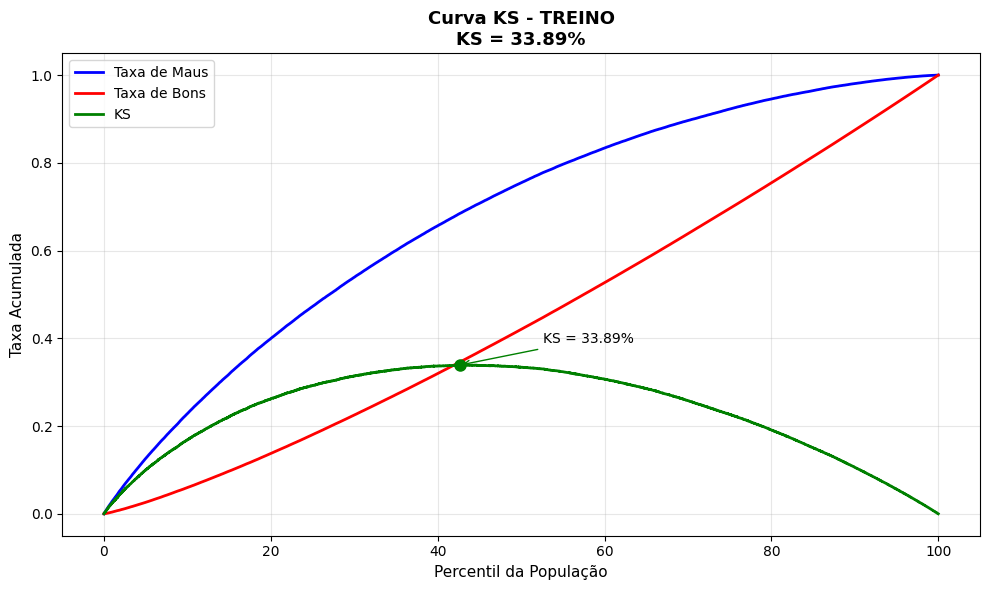


PROCESSANDO VALIDACAO
📋 Preparando features
🎯 Modelo espera 32 features
🔧 Criando features exatas...
  Score 01...
  Score 02...
  Idade...
  Ticket médio...
  SOS M6...
  Combo M6...
  Valor líquido...
  Valor aberto...
  Meses dados pagamento...
  Valor pago...
  Flag fraude...
🔄 Ordenando colunas...
✅ Features preparadas: (220658, 32)
🎯 Colunas: ['const', 'score_01_adj_cate_1', 'score_01_adj_cate_2', 'score_01_adj_cate_3', 'score_01_adj_cate_4', 'score_01_adj_cate_5', 'score_01_adj_cate_6', 'score_01_adj_cate_7', 'score_02_adj_cate_1', 'score_02_adj_cate_2', 'score_02_adj_cate_3', 'score_02_adj_cate_4', 'score_02_adj_cate_5', 'score_02_adj_cate_6', 'score_02_adj_cate_7', 'score_02_adj_cate_8', 'score_02_adj_cate_9', 'IDADE_cate_1', 'IDADE_cate_2', 'ticket_medio_m1_cate_1', 'ticket_medio_m1_cate_2', 'qtd_sos_m6_cate_1', 'qtd_combo_m6_cate_1', 'val_liquido_m6_cate_1', 'val_liquido_m6_cate_2', 'val_liquido_m6_cate_3', 'sum_val_aberto_mes_atr_m1_cate_1', 'qtd_meses_dados_pag_m6_cate_1'

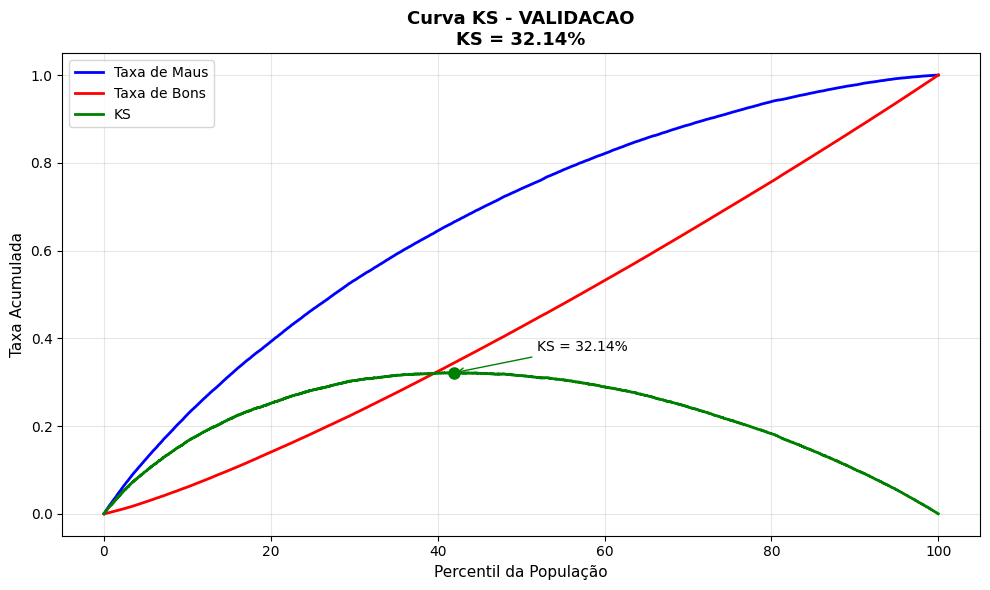


PROCESSANDO OOT
📋 Preparando features
🎯 Modelo espera 32 features
🔧 Criando features exatas...
  Score 01...
  Score 02...
  Idade...
  Ticket médio...
  SOS M6...
  Combo M6...
  Valor líquido...
  Valor aberto...
  Meses dados pagamento...
  Valor pago...
  Flag fraude...
🔄 Ordenando colunas...
✅ Features preparadas: (409953, 32)
🎯 Colunas: ['const', 'score_01_adj_cate_1', 'score_01_adj_cate_2', 'score_01_adj_cate_3', 'score_01_adj_cate_4', 'score_01_adj_cate_5', 'score_01_adj_cate_6', 'score_01_adj_cate_7', 'score_02_adj_cate_1', 'score_02_adj_cate_2', 'score_02_adj_cate_3', 'score_02_adj_cate_4', 'score_02_adj_cate_5', 'score_02_adj_cate_6', 'score_02_adj_cate_7', 'score_02_adj_cate_8', 'score_02_adj_cate_9', 'IDADE_cate_1', 'IDADE_cate_2', 'ticket_medio_m1_cate_1', 'ticket_medio_m1_cate_2', 'qtd_sos_m6_cate_1', 'qtd_combo_m6_cate_1', 'val_liquido_m6_cate_1', 'val_liquido_m6_cate_2', 'val_liquido_m6_cate_3', 'sum_val_aberto_mes_atr_m1_cate_1', 'qtd_meses_dados_pag_m6_cate_1', 'qtd

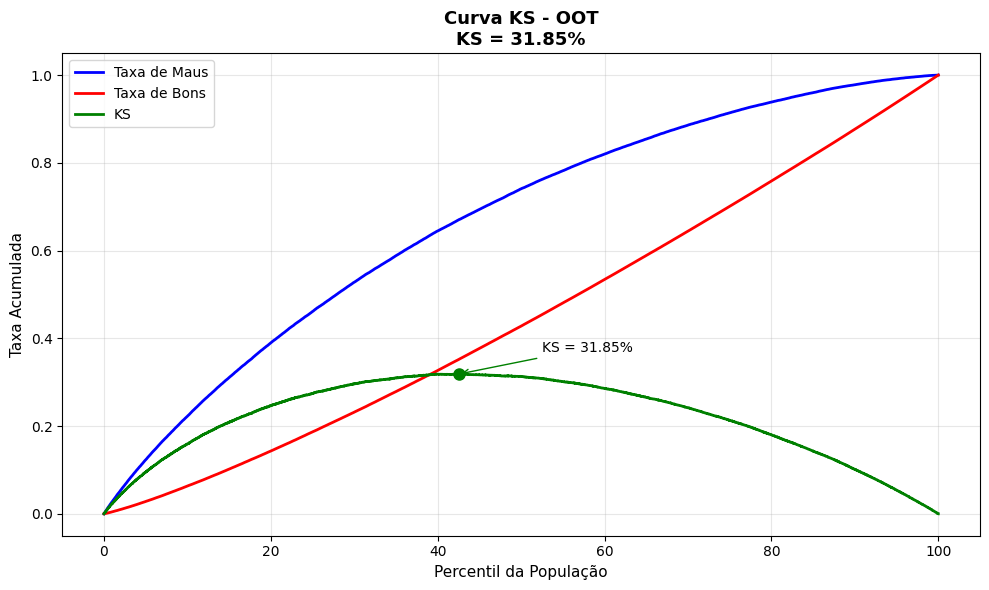


COMPARAÇÃO DE RESULTADOS
  Dataset KS (%)    AUC GINI (%) Accuracy F1-Score
   TREINO  33.89 0.7308    46.16    0.772    0.251
VALIDACAO  32.14 0.7202    44.04    0.773    0.237
      OOT  31.85 0.7169    43.39    0.776    0.219


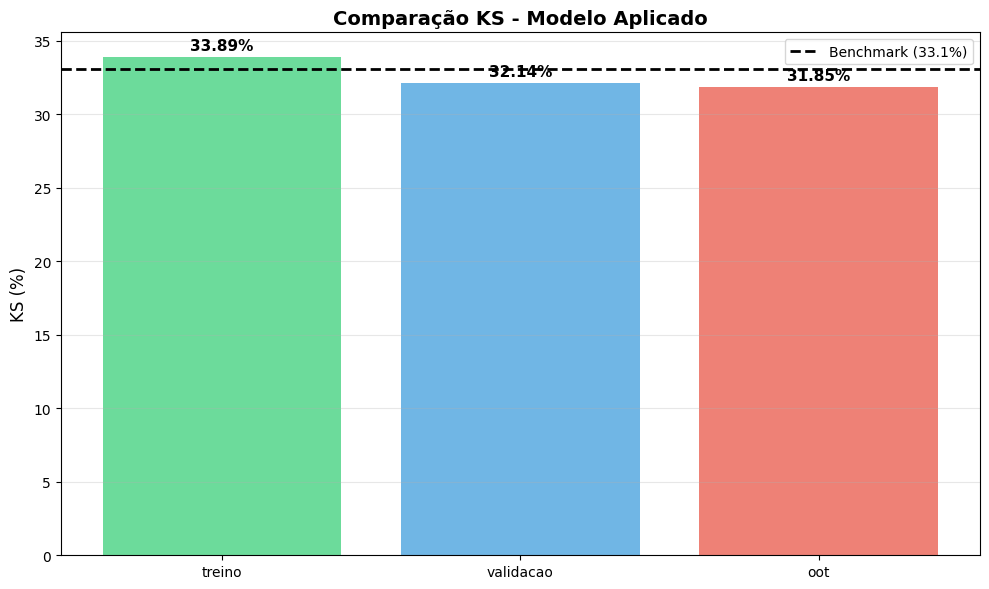


ADICIONANDO SCORE FINAL E GRUPOS HOMOGÊNEOS
🔧 Criando Grupos Homogêneos (GH)...
✅ Grupos Homogêneos criados
📊 Calculando PD_MEDIA por GH...
✅ PD_MEDIA calculada

📊 DISTRIBUIÇÃO DOS GRUPOS HOMOGÊNEOS:
     total  defaults  taxa_default_pct  ...  score_max  score_medio  pct_volume
GH                                      ...                                    
10  129438     69014              53.0  ...     549.96       461.84       10.05
9   103152     41825              41.0  ...     624.99       590.19        8.01
8    72216     25435              35.0  ...     664.97       645.42        5.61
7    76703     24289              32.0  ...     700.00       682.68        5.95
6   127731     35194              28.0  ...     749.98       725.63        9.91
5   151487     34498              23.0  ...     799.98       776.12       11.76
4   170997     30116              18.0  ...     849.98       825.58       13.27
3   190388     24503              13.0  ...     900.00       874.99       14.78

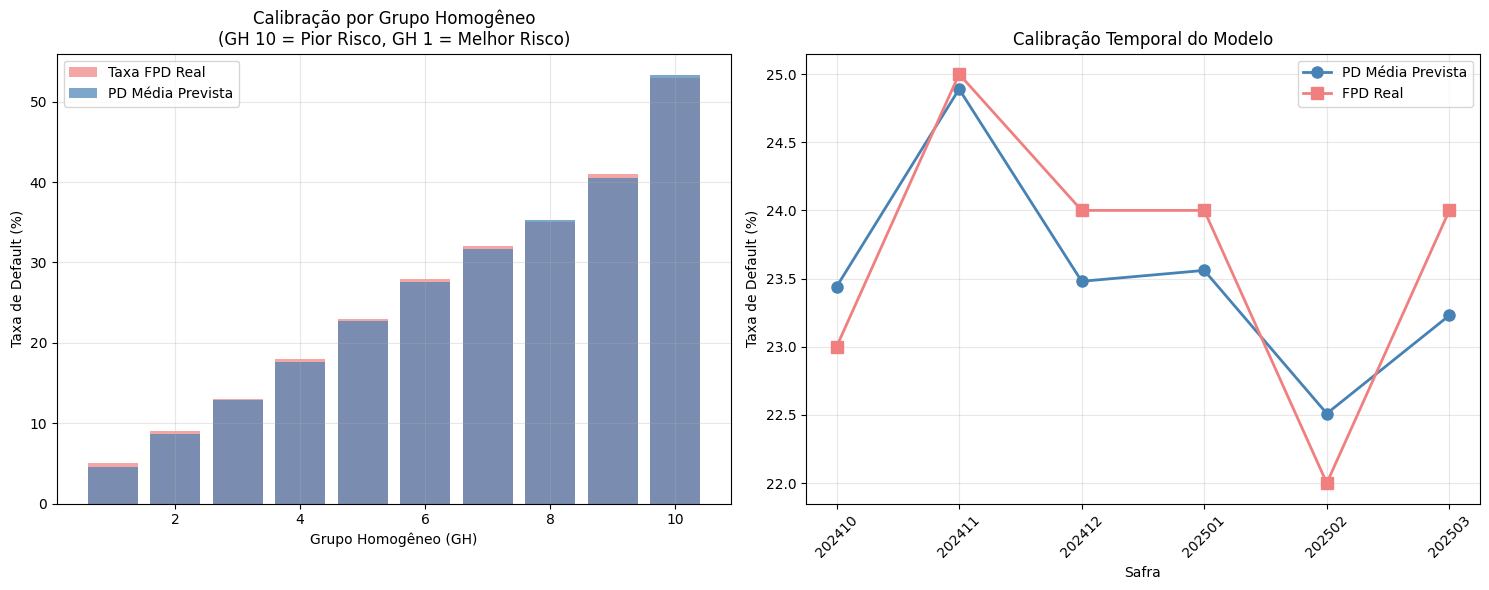

✅ Gráficos de calibração plotados

RESUMO FINAL DA APLICAÇÃO

🎯 PERFORMANCE DO MODELO:
   Treino:     KS = 33.89%
   Validação:  KS = 32.14%
   OOT:        KS = 31.85%
   
📊 BENCHMARK:
   Meta:       KS = 33.10%
   Atingido:   ❌ NÃO
   
🔧 CALIBRAÇÃO:
   Monotonicidade: ✅ OK
   Grupos:         10 faixas (GH 1-10)
   
📈 DATASETS:
   Total processado: 1,288,300 registros
   Treino:          657,689 registros
   Validação:       220,658 registros
   OOT:             409,953 registros
        

✅ Pipeline executado com sucesso!


In [0]:
executar_pipeline_completo()